In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import gc
from IPython.display import display, HTML

warnings.filterwarnings('ignore')

from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.base import clone

from sklearn.linear_model import LogisticRegression, Ridge
from xgboost import XGBClassifier, XGBRFClassifier, DMatrix
from catboost import CatBoostClassifier, Pool
from lightgbm import LGBMClassifier, early_stopping
from sklearn.ensemble import HistGradientBoostingClassifier

In [2]:
df_raw = pd.read_csv("train_loan.csv", on_bad_lines='warn', delimiter=',')
df_raw = df_raw.drop(["id"],axis=1)
df_raw.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,14,0
1,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,2,0
2,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,10,0
3,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,5,0
4,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,3,0


In [3]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  58645 non-null  int64  
 1   person_income               58645 non-null  int64  
 2   person_home_ownership       58645 non-null  object 
 3   person_emp_length           58645 non-null  float64
 4   loan_intent                 58645 non-null  object 
 5   loan_grade                  58645 non-null  object 
 6   loan_amnt                   58645 non-null  int64  
 7   loan_int_rate               58645 non-null  float64
 8   loan_percent_income         58645 non-null  float64
 9   cb_person_default_on_file   58645 non-null  object 
 10  cb_person_cred_hist_length  58645 non-null  int64  
 11  loan_status                 58645 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 5.4+ MB


In [4]:
df_raw.duplicated().sum()

0

In [5]:
df_raw.drop_duplicates(inplace=True)

In [6]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  58645 non-null  int64  
 1   person_income               58645 non-null  int64  
 2   person_home_ownership       58645 non-null  object 
 3   person_emp_length           58645 non-null  float64
 4   loan_intent                 58645 non-null  object 
 5   loan_grade                  58645 non-null  object 
 6   loan_amnt                   58645 non-null  int64  
 7   loan_int_rate               58645 non-null  float64
 8   loan_percent_income         58645 non-null  float64
 9   cb_person_default_on_file   58645 non-null  object 
 10  cb_person_cred_hist_length  58645 non-null  int64  
 11  loan_status                 58645 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 5.4+ MB


In [7]:
df_raw.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
loan_status                   0
dtype: int64

In [8]:
target = 'loan_status'

In [9]:
features = df_raw.drop(target, axis=1).columns.tolist()

In [10]:
categorical_features = df_raw.select_dtypes(include='object').columns.tolist()

In [11]:
numerical_features = list(set(features) - set(categorical_features))

In [12]:
df_raw.describe().T

,count,mean,std,min,25%,50%,75%,max
person_age,58645.0,27.550857,6.033216,20.00,23.00,26.00,30.00,123.00
person_income,58645.0,64046.172871,37931.106979,4200.00,42000.00,58000.00,75600.00,1900000.00
person_emp_length,58645.0,4.701015,3.959784,0.00,2.00,4.00,7.00,123.00
loan_amnt,58645.0,9217.556518,5563.807384,500.00,5000.00,8000.00,12000.00,35000.00
loan_int_rate,58645.0,10.677874,3.034697,5.42,7.88,10.75,12.99,23.22
loan_percent_income,58645.0,0.159238,0.091692,0.00,0.09,0.14,0.21,0.83
cb_person_cred_hist_length,58645.0,5.813556,4.029196,2.00,3.00,4.00,8.00,30.00
loan_status,58645.0,0.142382,0.349445,0.00,0.00,0.00,0.00,1.00


person_age 최대값 123세: 매우 비정상적인 값. 데이터 정리 필요.

person_emp_length 최대값 123년: 근속 기간 치고 비정상적으로 큼. 데이터 오류 가능성.

loan_percent_income 최대값 83%: 소득의 거의 대부분을 대출에 사용 → 높은 연체 위험 → 추가 분석 필요.

In [13]:
# Tìm các dòng thỏa mãn ít nhất một trong ba điều kiện
outlier_rows = df_raw[
    (df_raw['person_age'] == 123) |
    (df_raw['person_emp_length'] == 123)
]

# Hiển thị kết quả
print(f"Tổng số dòng thỏa mãn điều kiện: {len(outlier_rows)}")
display(outlier_rows)


Tổng số dòng thỏa mãn điều kiện: 3


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
41079,28,60350,MORTGAGE,123.0,MEDICAL,D,25000,15.95,0.35,Y,6,1
47336,123,36000,MORTGAGE,7.0,PERSONAL,B,6700,10.75,0.18,N,4,0
49252,21,192000,MORTGAGE,123.0,VENTURE,B,20000,11.49,0.10,N,2,0


In [14]:
df_raw = df_raw[
    (df_raw['person_age'] != 123) &
    (df_raw['person_emp_length'] != 123) &
    (df_raw['loan_percent_income'] != 0.83)
]
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
Index: 58641 entries, 0 to 58644
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  58641 non-null  int64  
 1   person_income               58641 non-null  int64  
 2   person_home_ownership       58641 non-null  object 
 3   person_emp_length           58641 non-null  float64
 4   loan_intent                 58641 non-null  object 
 5   loan_grade                  58641 non-null  object 
 6   loan_amnt                   58641 non-null  int64  
 7   loan_int_rate               58641 non-null  float64
 8   loan_percent_income         58641 non-null  float64
 9   cb_person_default_on_file   58641 non-null  object 
 10  cb_person_cred_hist_length  58641 non-null  int64  
 11  loan_status                 58641 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 5.8+ MB


In [15]:
df_raw[categorical_features].describe(include='O').T

,count,unique,top,freq
person_home_ownership,58641,4,RENT,30593
loan_intent,58641,6,EDUCATION,12271
loan_grade,58641,7,A,20984
cb_person_default_on_file,58641,2,N,49940


person_home_ownership:
임대(Rent) 거주자가 많습니다.

loan_intent:
교육 목적 대출이 가장 많습니다. 이 그룹의 실제 연체율을 비교 분석하는 것이 중요합니다.

loan_grade:
A 등급이 많지만, 등급이 낮은 E, F, G 그룹에서 연체율이 높을 가능성이 있습니다. 추가 분석 필요합니다.

cb_person_default_on_file:
대부분 과거 연체 기록이 없다

In [16]:
for col in categorical_features:
    display(df_raw.groupby(col)[['loan_amnt', 'loan_int_rate']].agg(['min', 'mean', 'max']))

loan_amnt                      loan_int_rate             \
                            min          mean    max           min       mean   
person_home_ownership                                                           
MORTGAGE                   1000   9962.390718  35000          5.42   9.958104   
OTHER                      1000  10028.651685  25000          5.79  11.561348   
OWN                        1000   8740.431804  35000          5.42  10.707307   
RENT                        500   8658.823162  35000          5.42  11.256051   

                              
                         max  
person_home_ownership         
MORTGAGE               21.74  
OTHER                  20.52  
OWN                    20.11  
RENT                   23.22

loan_amnt                      loan_int_rate             \
                        min          mean    max           min       mean   
loan_intent                                                                 
DEBTCONSOLIDATION      1000   9150.314793  35000          5.42  10.613230   
EDUCATION              1000   9051.681363  35000          5.42  10.681510   
HOMEIMPROVEMENT        1000  10224.007962  35000          5.42  10.881809   
MEDICAL                 700   8818.510473  35000          5.42  10.742353   
PERSONAL               1000   9239.379868  35000          5.42  10.607043   
VENTURE                 500   9261.758242  35000          5.42  10.604266   

                          
                     max  
loan_intent               
DEBTCONSOLIDATION  21.74  
EDUCATION          21.74  
HOMEIMPROVEMENT    22.11  
MEDICAL            21.36  
PERSONAL           22.06  
VENTURE            23.22

loan_amnt                      loan_int_rate                  
                 min          mean    max           min       mean    max
loan_grade                                                               
A                700   8447.103746  35000          5.42   7.335176  19.04
B               1000   9622.120159  35000          5.99  11.034724  17.56
C                500   9009.261441  35000          5.79  13.510590  16.29
D               1000  10518.591297  35000          6.00  15.404490  19.13
E               1000  12176.313181  35000          7.88  16.930961  23.06
F               1750  12833.892617  30000         15.01  18.610940  22.06
G               1500  12559.090909  30000         18.07  20.327576  23.22

loan_amnt                     loan_int_rate  \
                                min         mean    max           min   
cb_person_default_on_file                                               
N                               500  9170.173849  35000          5.42   
Y                              1000  9485.969429  35000          5.99   

                                             
                                mean    max  
cb_person_default_on_file                    
N                          10.042120  21.74  
Y                          14.326113  23.22

임차인(RENT)은 담보 대출자(MORTGAGE)보다 이자율이 더 높습니다.

창업(VENTURE) 목적 대출은 이자율이 낮다

등급이 낮을수록(E, F, G) 대출 금액은 커지고, 이자율은 매우 높아짐

과거 연체 경험이 있는 고객(Y) 은 이자율이 크게 높습니다

Target Distribution

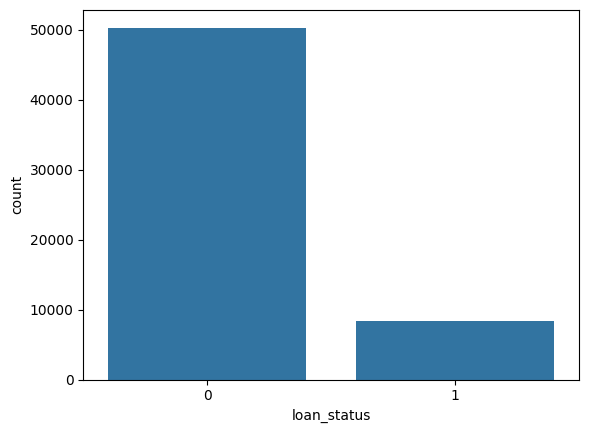

In [17]:
sns.countplot(df_raw, x=target)
plt.show()

그래프는 loan_status 변수의 심각한 클래스 불균형을 보여줍니다.

loan_status = 0: 대부분의 데이터 → 대출이 거절된 사례.

loan_status = 1: 소수의 데이터 → 대출이 승인된 사례.

이는 전형적인 불균형 데이터 문제입니다. 이를 처리하지 않으면:

머신러닝 모델이 "0"만 예측하려는 편향된 학습을 할 수 있습니다.

실제로 대출을 승인해야 할 "1" 케이스를 정확히 분류하지 못합니다.

📌 해결 방법 제안:

다음과 같은 기법을 사용할 수 있습니다:

Oversampling (예: SMOTE)

Undersampling

클래스 가중치 조정

평가 지표로는 정확도(accuracy) 외에 F1-score, 재현율(recall), AUC 등을 고려해야 합니다.

Distribution of Numerical Features

In [18]:
print(df_raw[numerical_features].head())


   loan_percent_income  person_age  person_emp_length  loan_amnt  \
0                 0.17          37                0.0       6000   
1                 0.07          22                6.0       4000   
2                 0.21          29                8.0       6000   
3                 0.17          30               14.0      12000   
4                 0.10          22                2.0       6000   

   cb_person_cred_hist_length  person_income  loan_int_rate  
0                          14          35000          11.49  
1                           2          56000          13.35  
2                          10          28800           8.90  
3                           5          70000          11.11  
4                           3          60000           6.92  


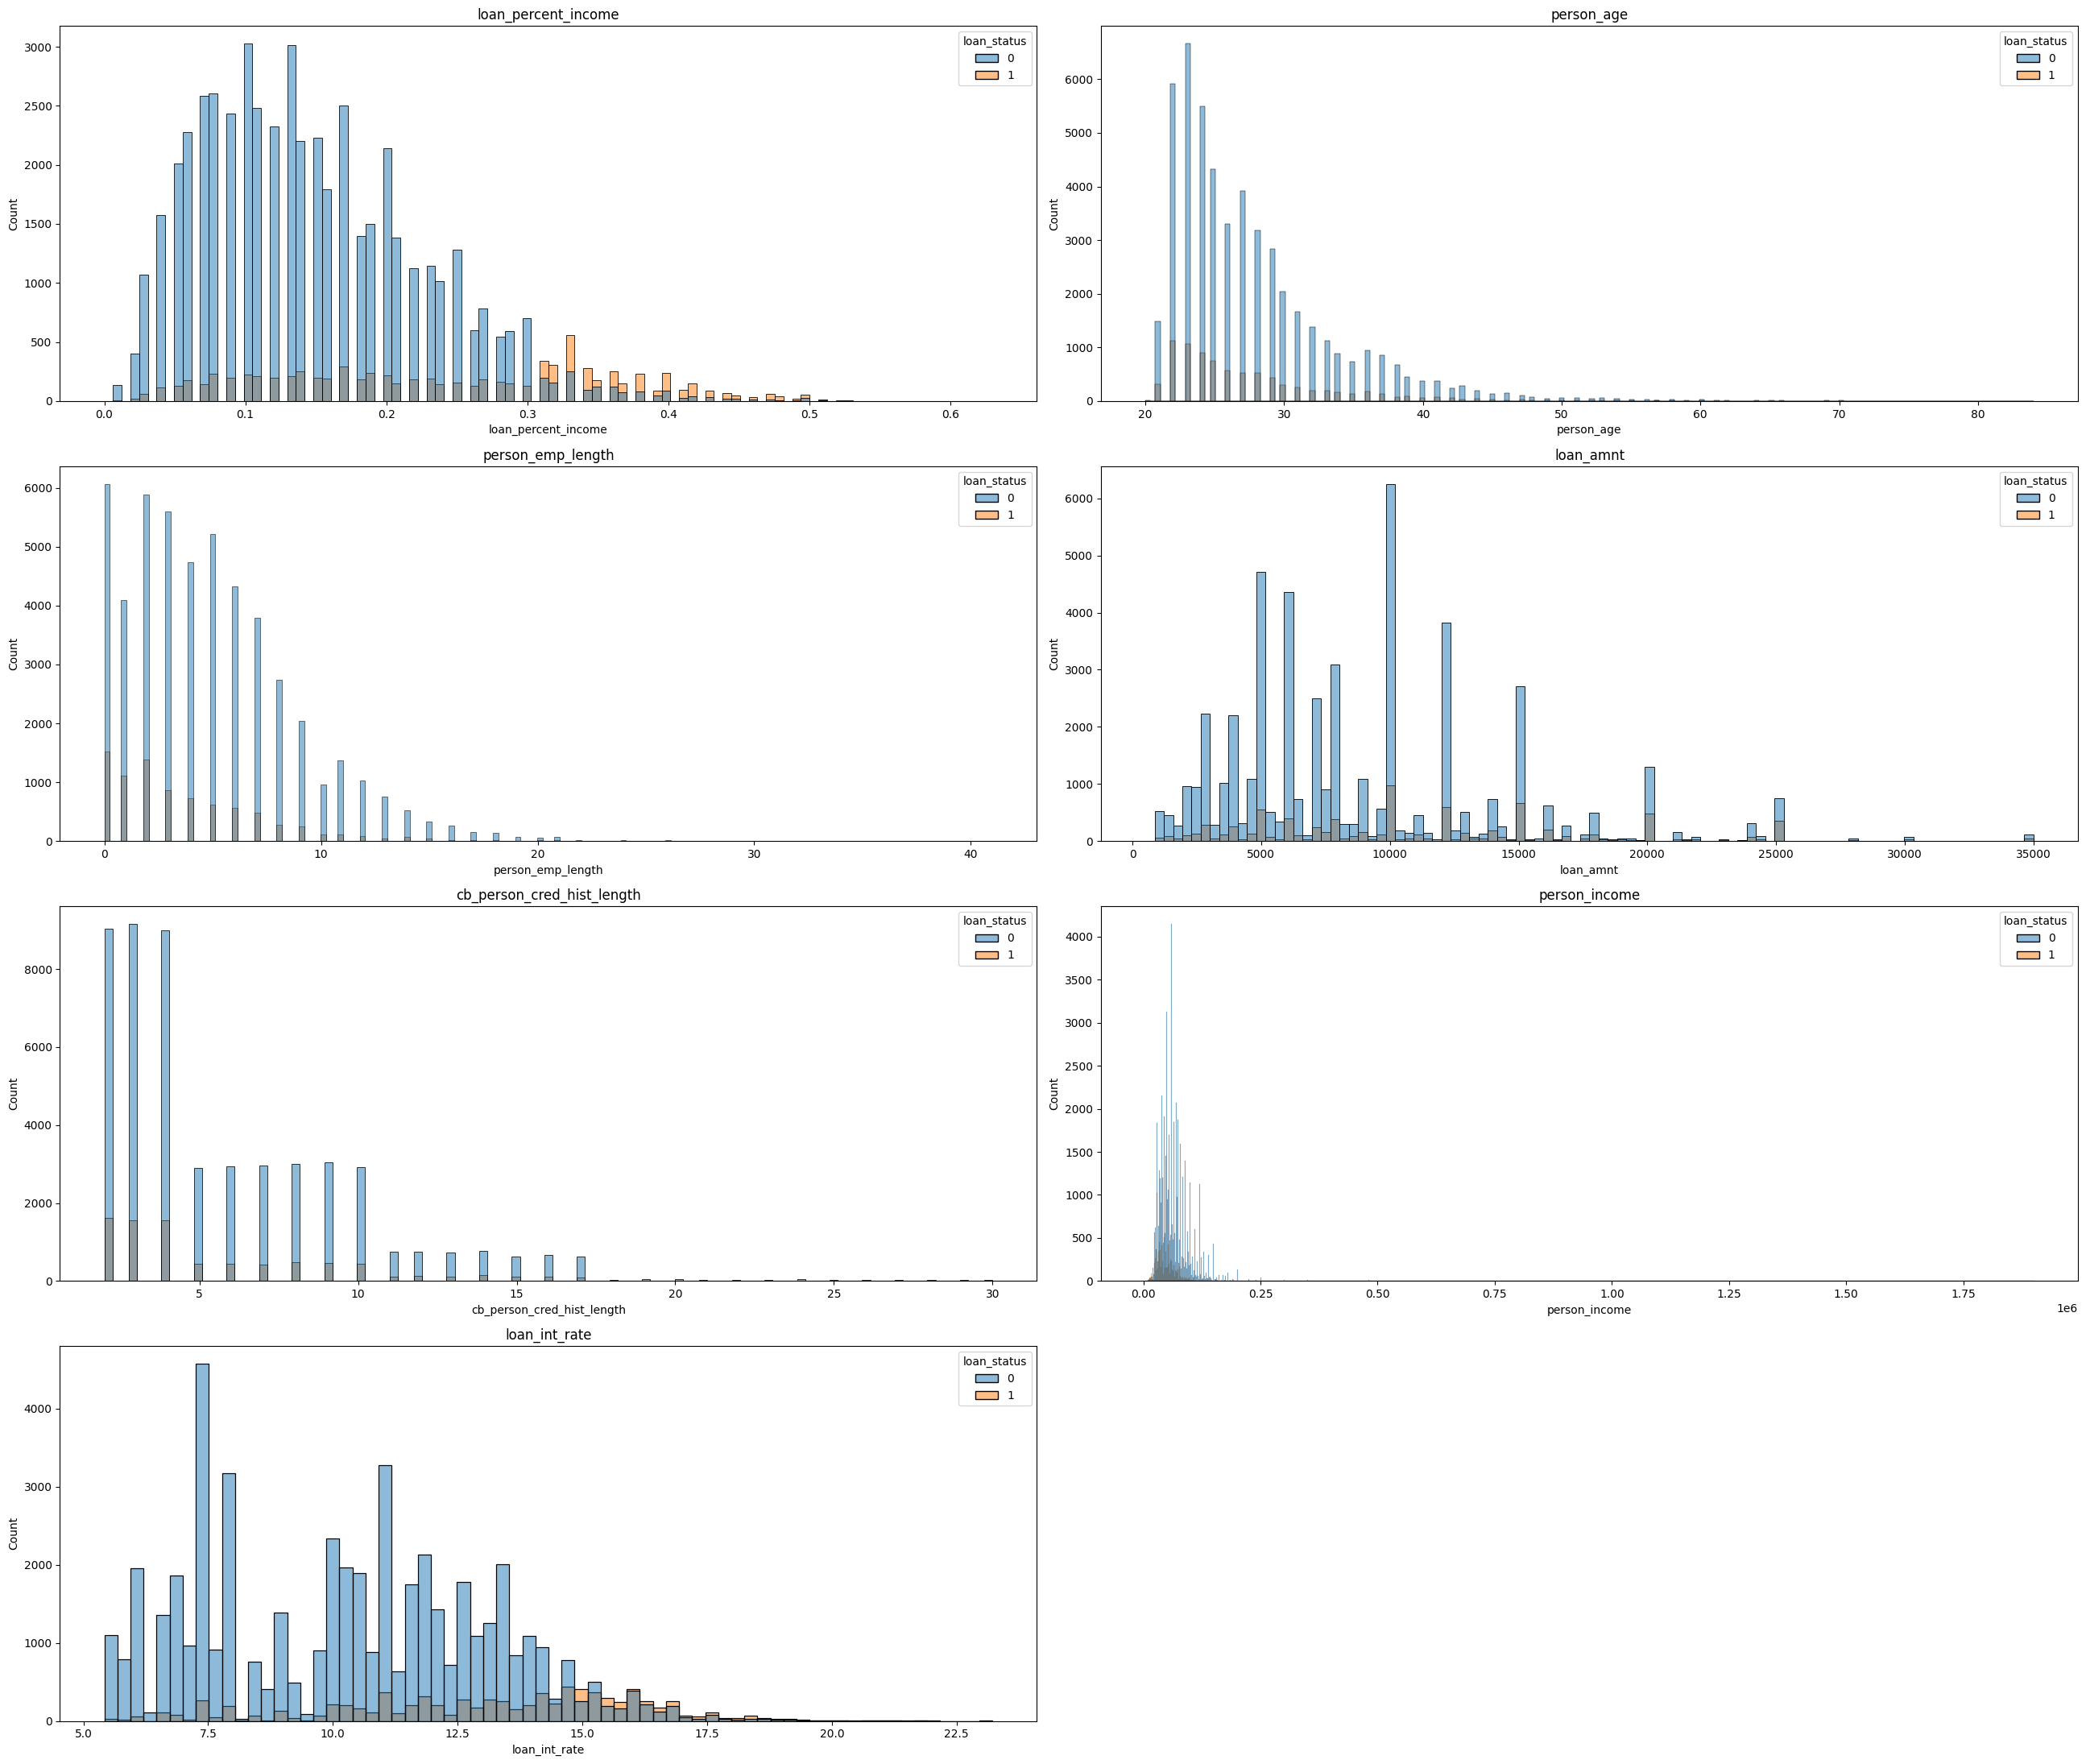

In [19]:
plt.figure(figsize=(26, 22))

for i, col in enumerate(numerical_features):
    plt.subplot(4,2, i+1)
    sns.histplot(df_raw, x=col, hue=target)
    plt.title(col)

plt.tight_layout()
plt.show()

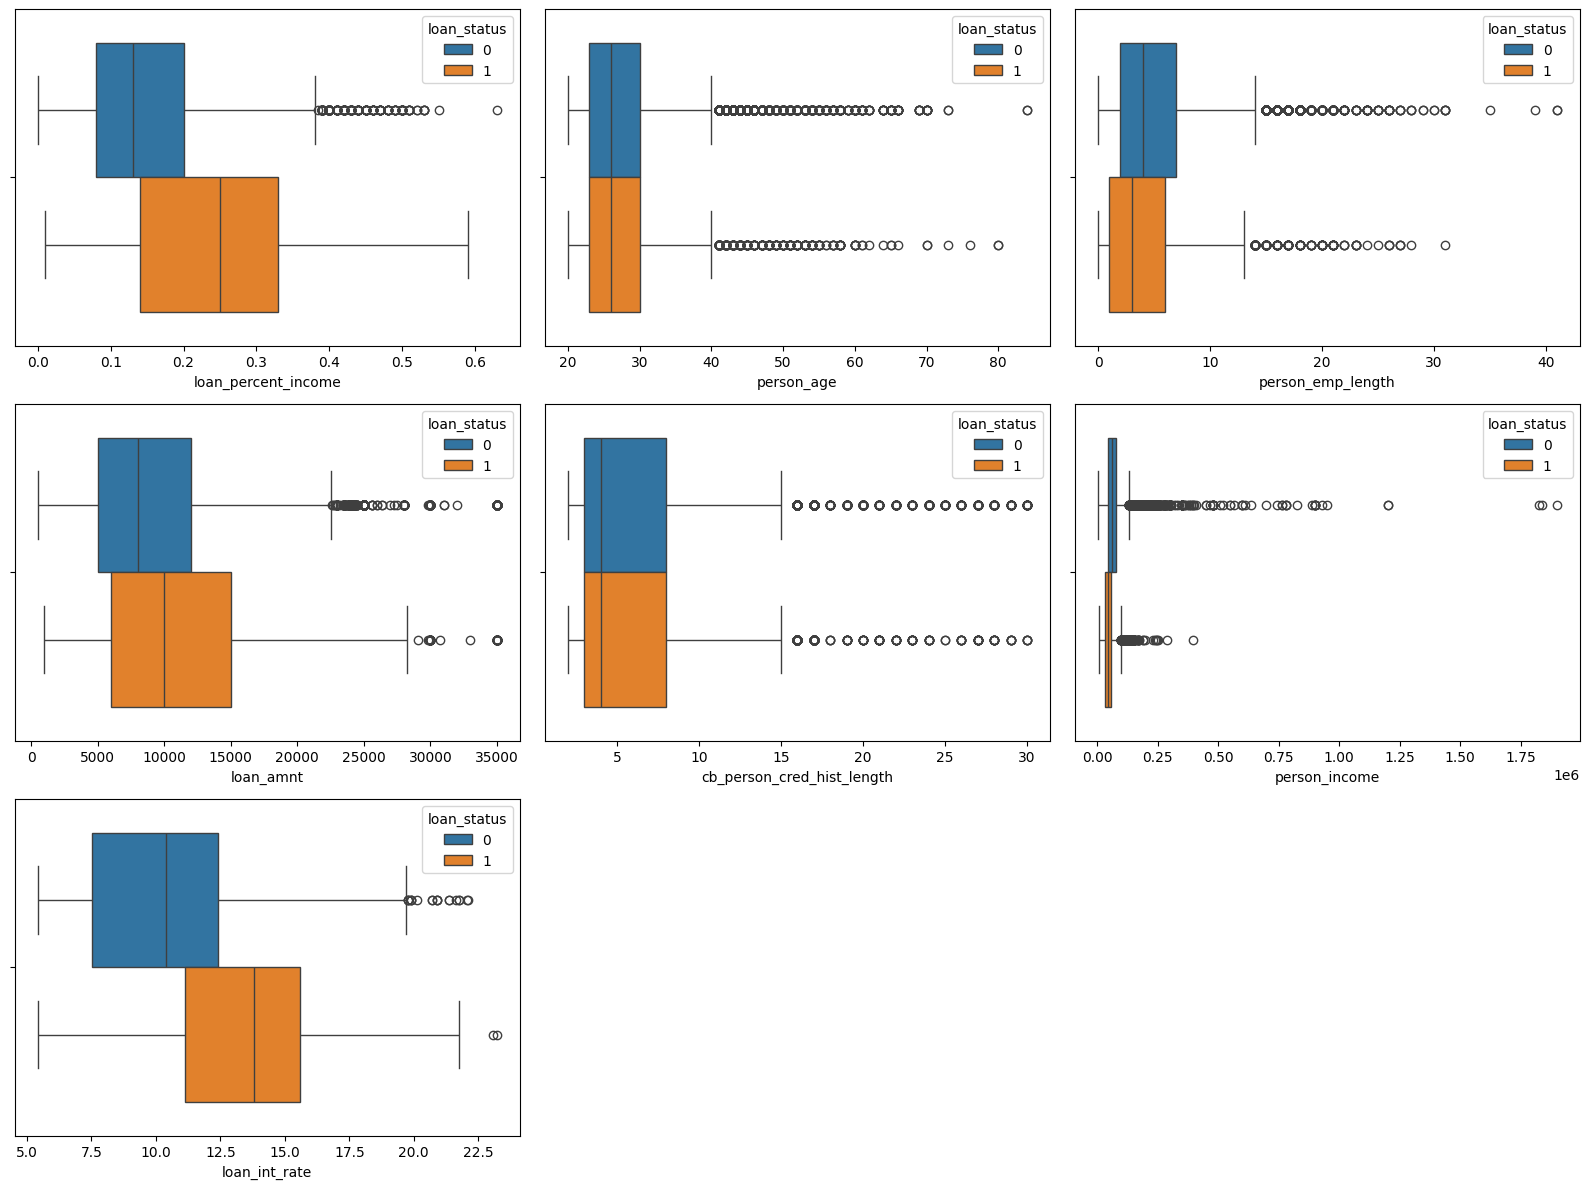

In [20]:
plt.figure(figsize=(16, 12))

for i, col in enumerate(numerical_features):
    plt.subplot(3, 3, i+1)
    sns.boxplot(df_raw, x=col, hue=target)

plt.tight_layout()
plt.show()

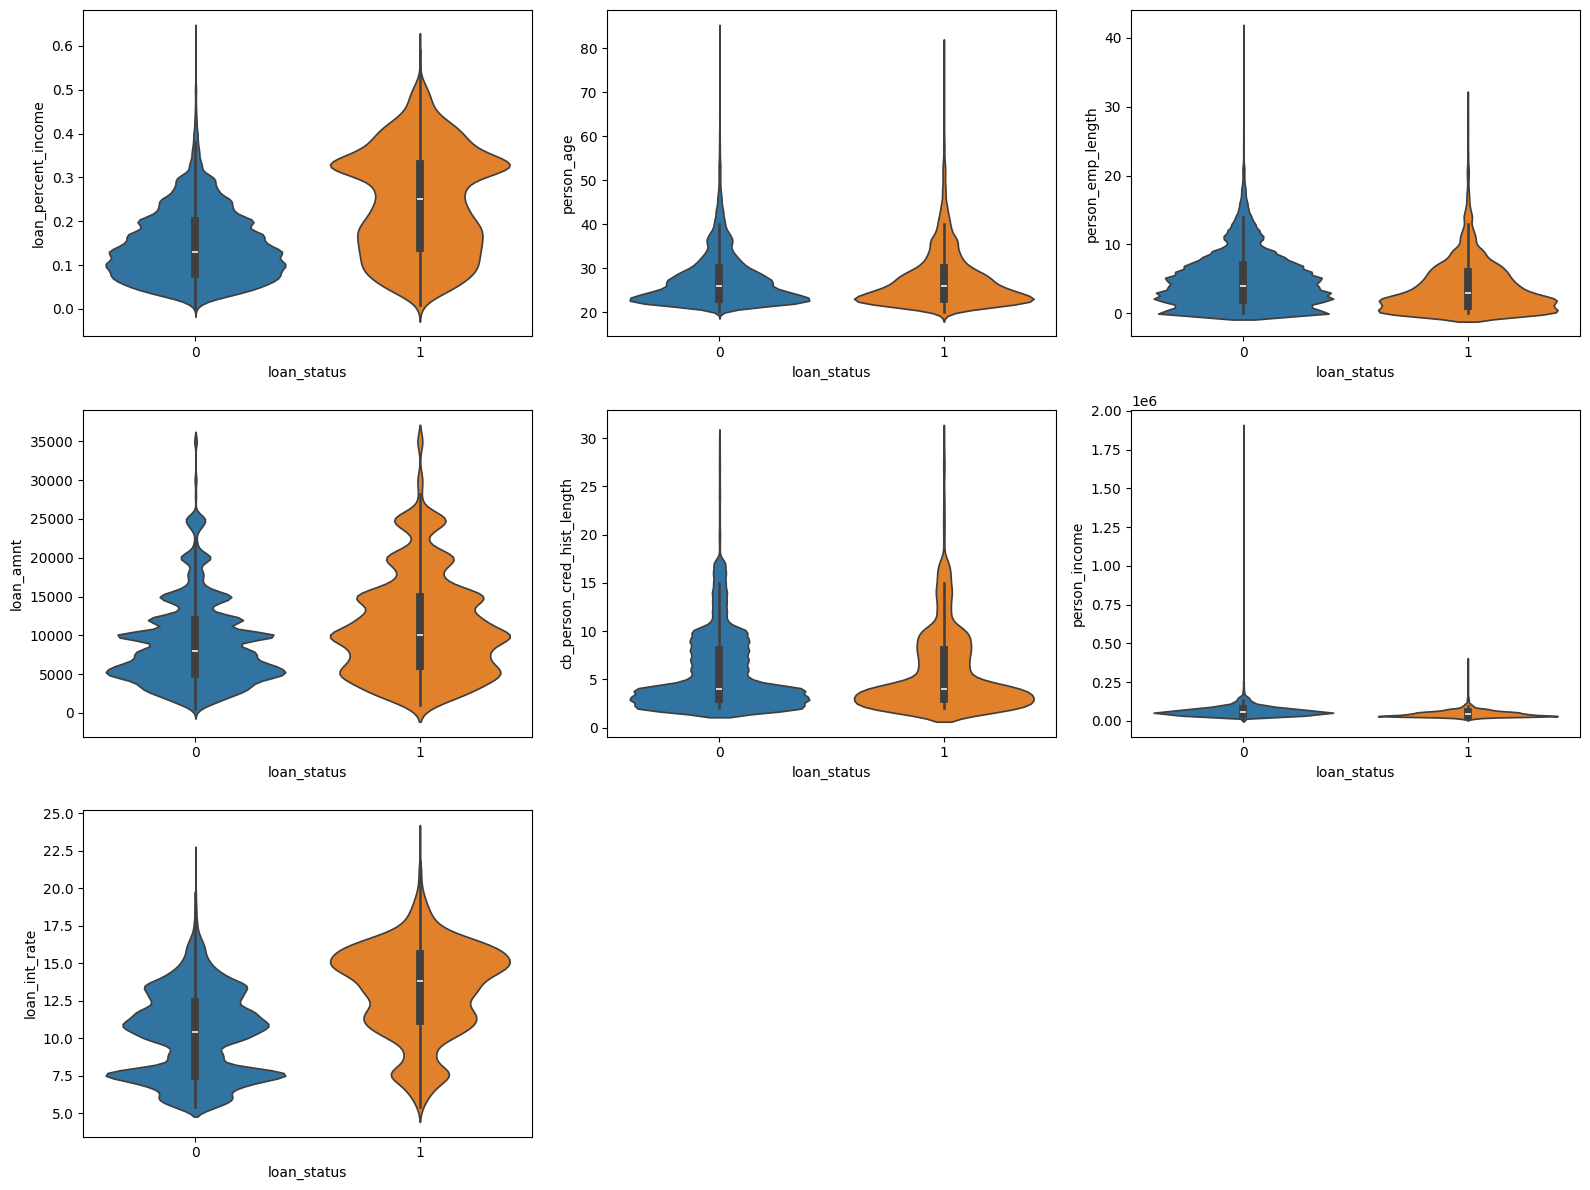

In [21]:
plt.figure(figsize=(16, 12))

for i, col in enumerate(numerical_features):
    plt.subplot(3, 3, i+1)
    sns.violinplot(df_raw, x=target, y=col, hue=target, legend=None)

plt.tight_layout()
plt.show()

1. loan_int_rate (이자율):
대출 승인(loan_status = 1) 받은 고객은 이자율이 더 높은 경향을 보임.

높은 이자율 = 높은 위험이지만, 다른 요소로 보완되었을 가능성 있음.

2. loan_percent_income (소득 대비 대출 비율):
대출 승인 그룹은 대출 비율이 더 높음 → 더 많은 리스크를 감수한 고객군.

3. cb_person_cred_hist_length (신용 이력 길이):
승인된 사람들의 신용 이력이 더 짧은 경향 있음. 전통적인 기준과는 반대 → 분석 추가 필요.

4. person_income (연소득):
두 그룹 간 소득 차이는 명확하지 않지만, 거절 그룹에서 극단적으로 높은 소득이 존재.

5. loan_amnt (대출 금액):
승인된 그룹에서 더 큰 금액을 대출받는 경향이 있음.

6. person_age 및 person_emp_length:
승인 그룹은 나이가 더 어리고, 근속 연수도 짧은 편 → 젊은 고객층 중심?

Distribution of Categorical Features

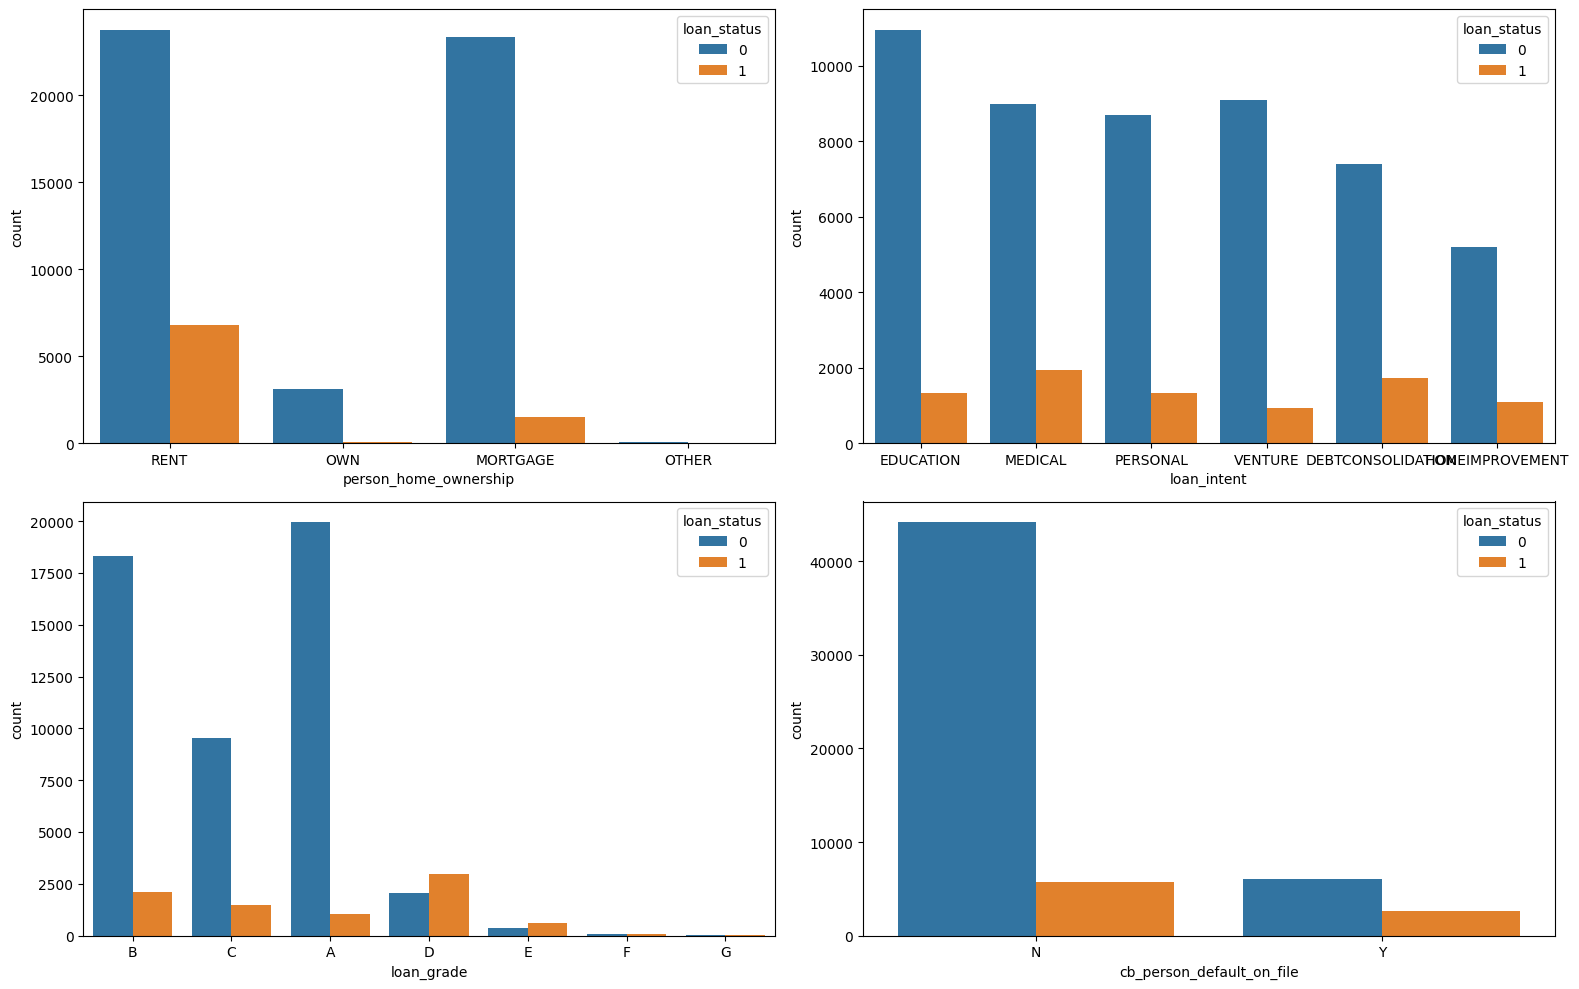

In [22]:
plt.figure(figsize=(16, 10))

for i, col in enumerate(categorical_features):
    plt.subplot(2, 2, i+1)
    sns.countplot(df_raw, x=col, hue=target)

plt.tight_layout()
plt.show()

MEDICAL, DEBTCONSOLIDATION, RENT, 그리고 loan_grade = D 와 같은 그룹은 예상보다 높은 대출 승인율을 보였습니다.

반면에, VENTURE(창업 목적) 와 연체 이력 있음(Y) 같은 요소는 여전히 제한적이지만, 완전히 배제되지는 않았습니다

Correlation Matrix

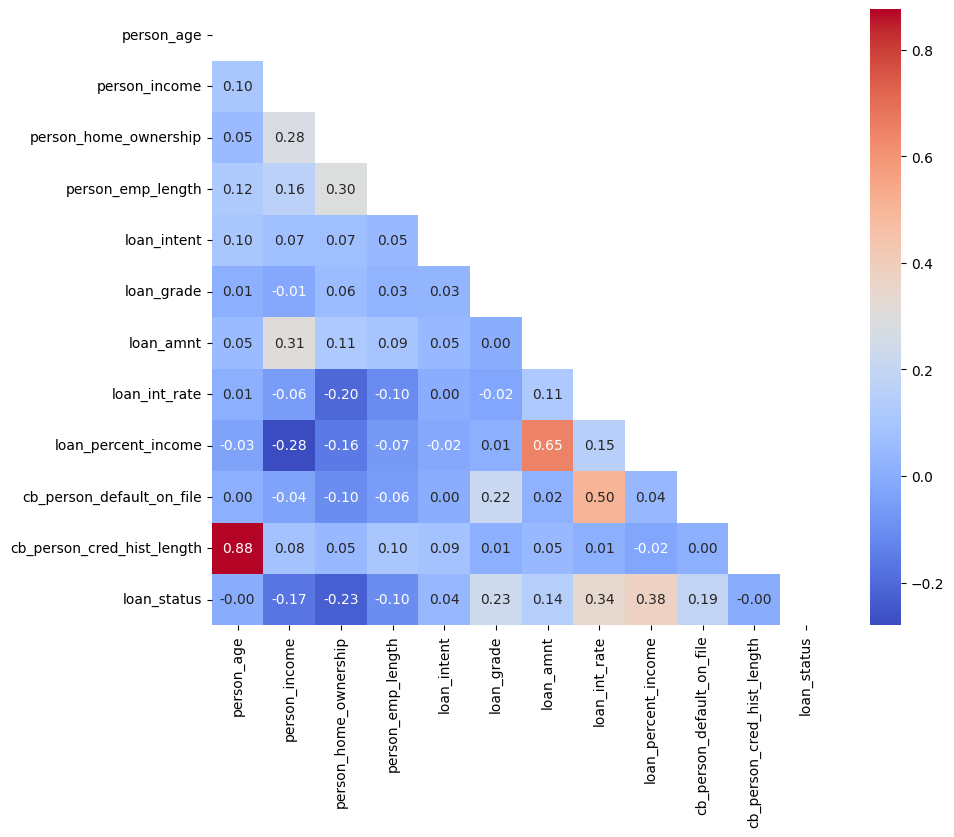

In [23]:
train_new = df_raw.copy()

for col in categorical_features:
    train_new[col], _ = train_new[col].factorize()

cor_mat = train_new.corr()
mask = np.triu(cor_mat)

plt.figure(figsize=(10, 8))
sns.heatmap(cor_mat, fmt='.2f', annot=True, mask=mask, cmap='coolwarm')
plt.show()

loan_percent_income과 loan_int_rate 간 강한 양의 상관관계 (0.65) → 대출 비율이 높으면 이자율도 높아지는 경향.

person_age와 cb_person_cred_hist_length 간 매우 강한 상관관계 (0.87) → 나이가 많을수록 신용 이력이 길어짐.

In [24]:
df_raw = df_raw.drop(columns='cb_person_cred_hist_length')
df_raw.info

<bound method DataFrame.info of        person_age  person_income person_home_ownership  person_emp_length  \
0              37          35000                  RENT                0.0   
1              22          56000                   OWN                6.0   
2              29          28800                   OWN                8.0   
3              30          70000                  RENT               14.0   
4              22          60000                  RENT                2.0   
...           ...            ...                   ...                ...   
58640          34         120000              MORTGAGE                5.0   
58641          28          28800                  RENT                0.0   
58642          23          44000                  RENT                7.0   
58643          22          30000                  RENT                2.0   
58644          31          75000              MORTGAGE                2.0   

      loan_intent loan_grade  loan_amnt  lo

In [25]:
df_raw.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,loan_status
0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,0
1,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,0
2,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,0
3,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,0
4,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,0


Outlier threshold: <-8400.0 or >126000.0
Số lượng outlier: 2410


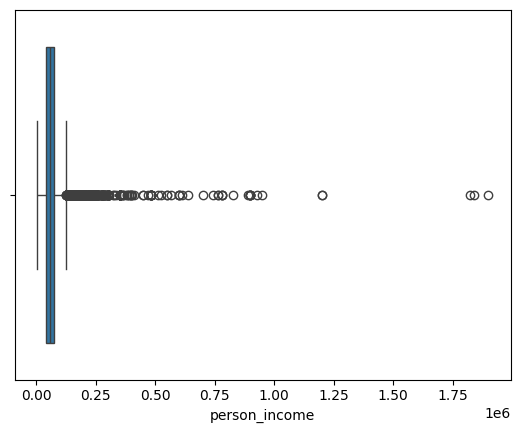

In [26]:
import numpy as np
import seaborn as sns

# Boxplot
sns.boxplot(x=df_raw['person_income'])

# IQR
Q1 = df_raw['person_income'].quantile(0.25)
Q3 = df_raw['person_income'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

print(f"Outlier threshold: <{lower} or >{upper}")

outliers = df_raw[(df_raw['person_income'] < lower) | (df_raw['person_income'] > upper)]
print(f"Số lượng outlier: {len(outliers)}")


In [27]:
df_cleaned = df_raw[(df_raw['person_income'] >= 0) & (df_raw['person_income'] <= 126000)]


In [28]:
df_cleaned.head()


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,loan_status
0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,0
1,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,0
2,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,0
3,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,0
4,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,0


In [29]:
print(numerical_features)
numerical_features.remove('cb_person_cred_hist_length')
print(numerical_features)

['loan_percent_income', 'person_age', 'person_emp_length', 'loan_amnt', 'cb_person_cred_hist_length', 'person_income', 'loan_int_rate']
['loan_percent_income', 'person_age', 'person_emp_length', 'loan_amnt', 'person_income', 'loan_int_rate']


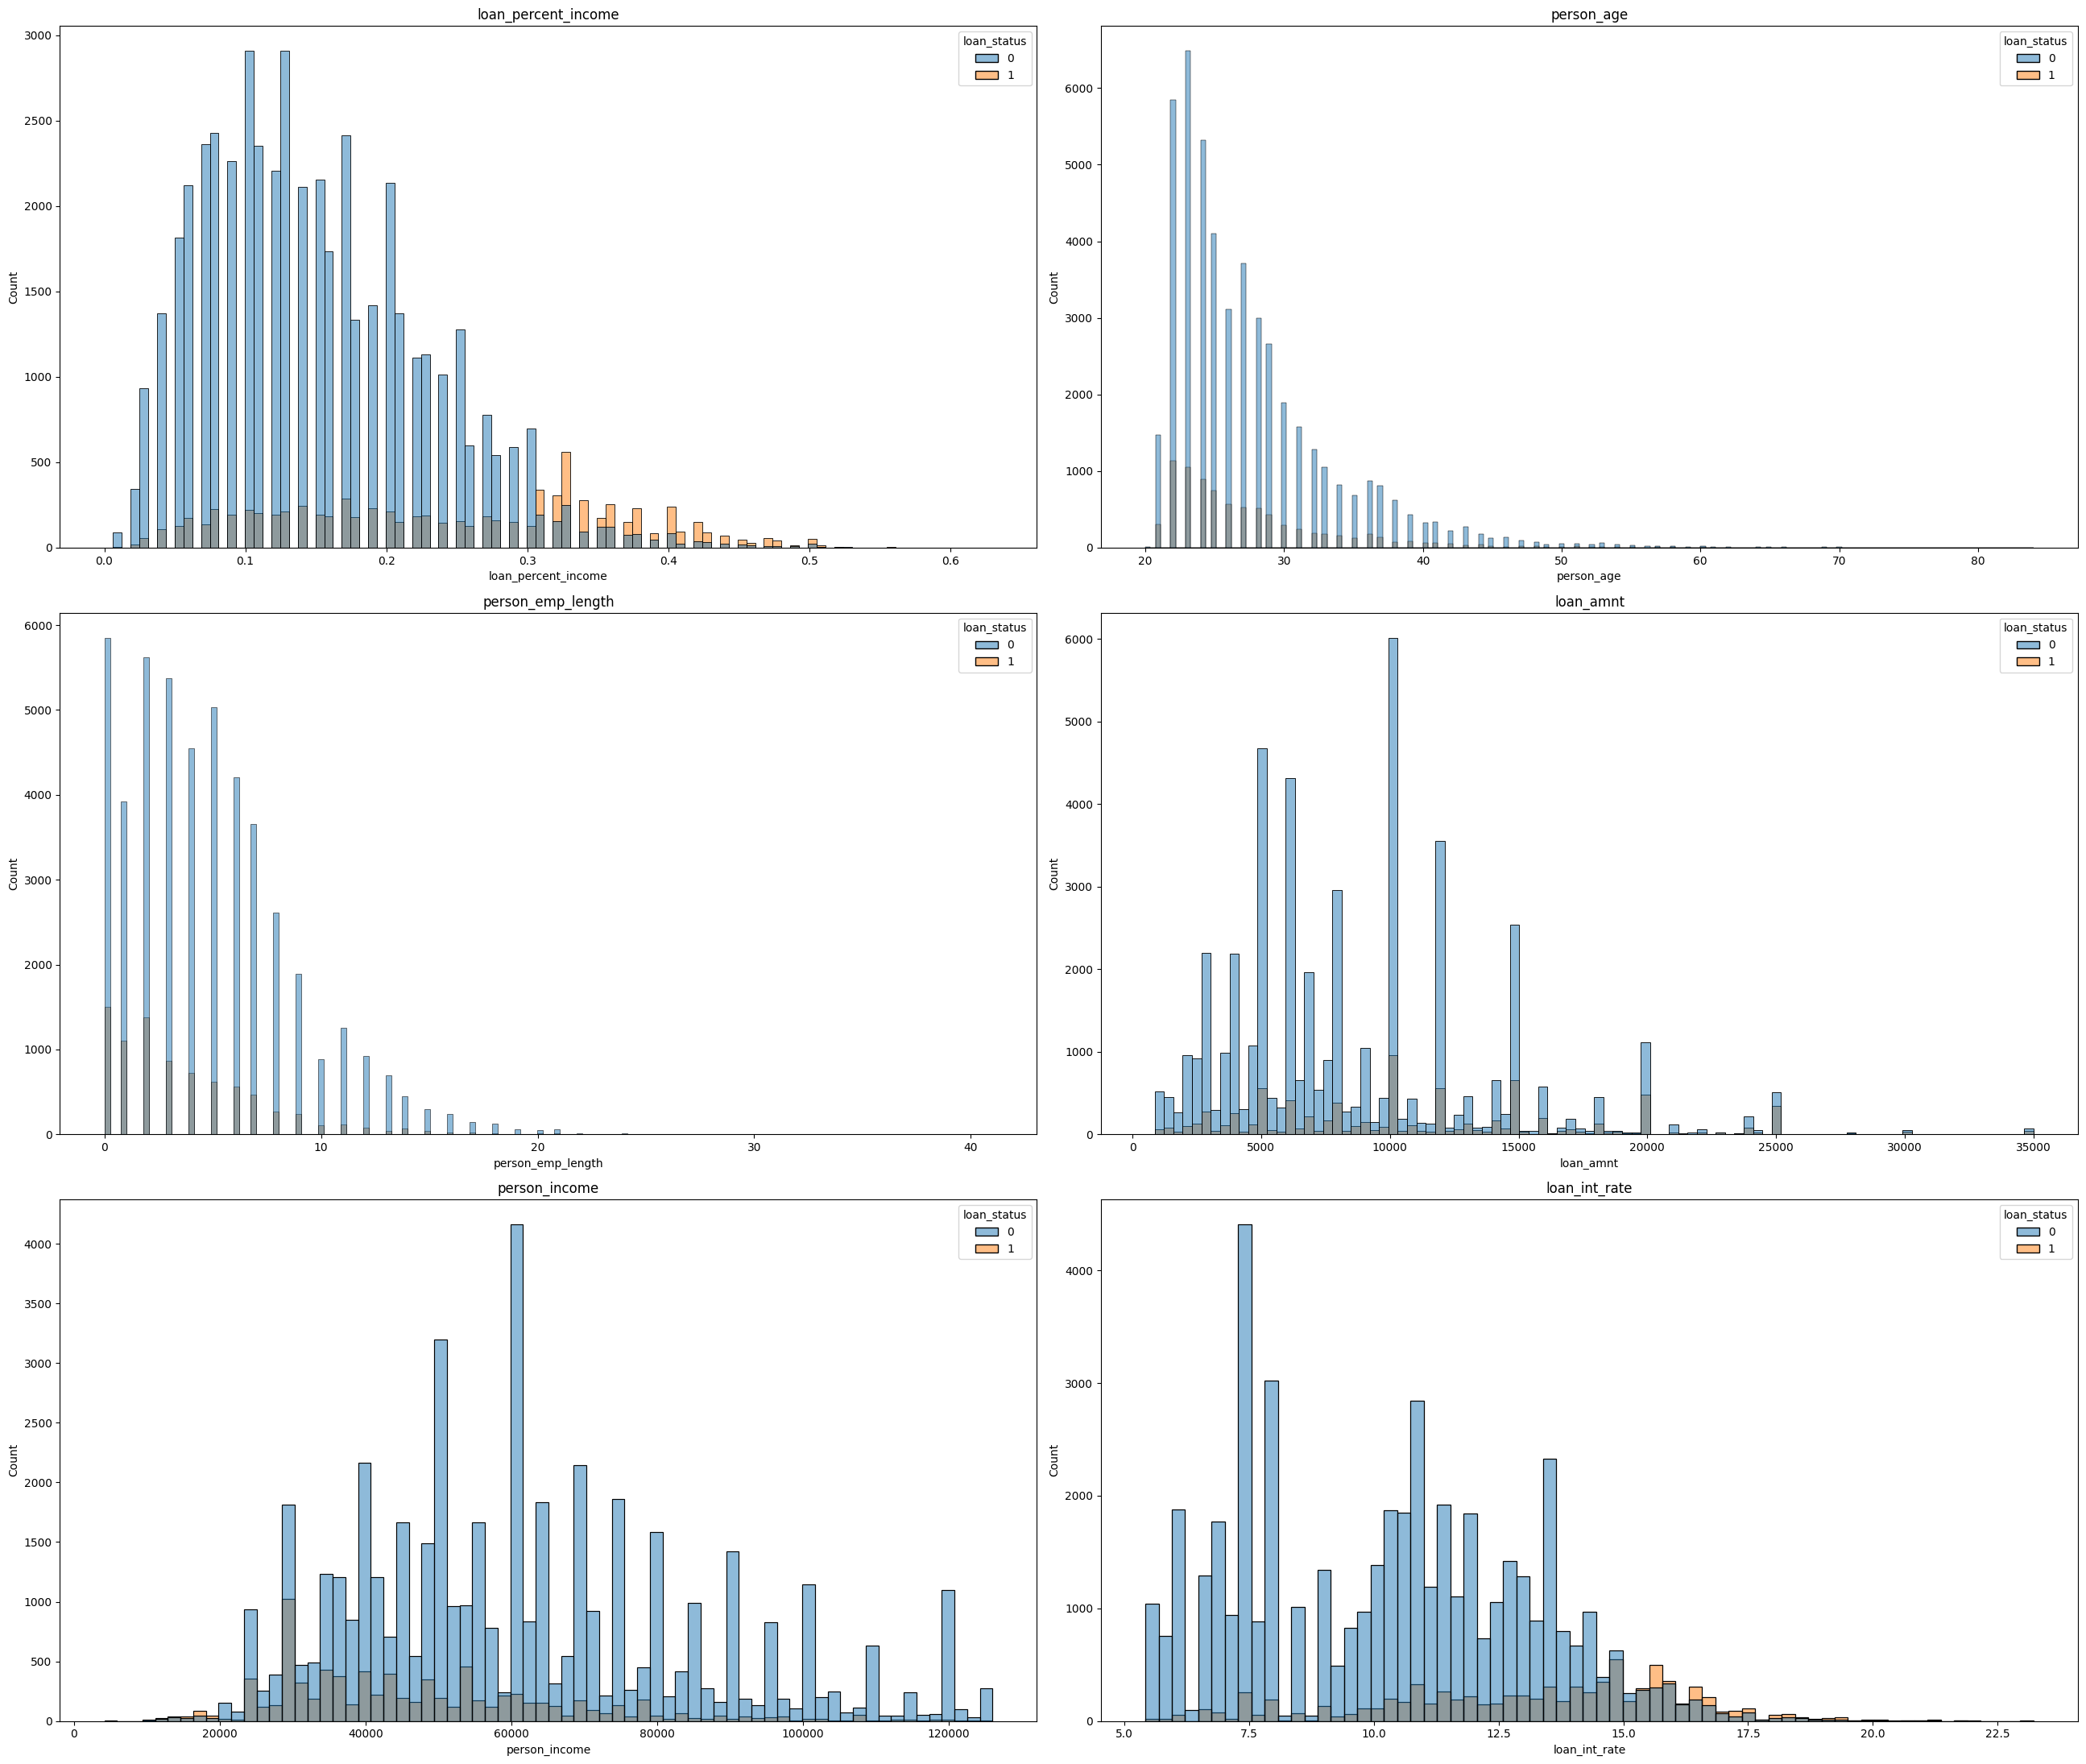

In [30]:
plt.figure(figsize=(26, 22))

for i, col in enumerate(numerical_features):
    plt.subplot(3,2, i+1)
    sns.histplot(df_cleaned, x=col, hue=target)
    plt.title(col)

plt.tight_layout()
plt.show()

In [31]:
import pandas as pd
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Tách dữ liệu
X = df_cleaned.drop(columns='loan_status')
y = df_cleaned['loan_status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Chia các cột
categorical_cols = X.select_dtypes(include='object').columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Tiền xử lý: Dùng Label Encoding thay vì OneHotEncoding
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])


# Tiền xử lý + SMOTE
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# SMOTE trên tập train
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_processed, y_train)



# Kiểm tra lại số lượng sau khi cân bằng
print(pd.Series(y_train_smote).value_counts())


loan_status
0    38382
1    38382
Name: count, dtype: int64


In [32]:
import numpy as np

def calculate_ks(y_true, y_probs):
    # Tạo DataFrame để tính toán
    df = pd.DataFrame({'label': y_true, 'prob': y_probs})
    df = df.sort_values(by='prob', ascending=False).reset_index(drop=True)
    
    # Tính tỷ lệ tích lũy của nhóm 1 (Bad) và nhóm 0 (Good)
    df['cum_bad'] = (df['label'] == 1).cumsum() / (df['label'] == 1).sum()
    df['cum_good'] = (df['label'] == 0).cumsum() / (df['label'] == 0).sum()
    
    # KS là khoảng cách lớn nhất giữa 2 đường tích lũy
    ks = max(abs(df['cum_bad'] - df['cum_good']))
    return ks


=== Logistic Regression ===
              precision    recall  f1-score   support

           0      0.962     0.842     0.898      9583
           1      0.470     0.806     0.594      1664

    accuracy                          0.837     11247
   macro avg      0.716     0.824     0.746     11247
weighted avg      0.889     0.837     0.853     11247


=== Random Forest ===
              precision    recall  f1-score   support

           0      0.952     0.977     0.964      9583
           1      0.846     0.715     0.775      1664

    accuracy                          0.939     11247
   macro avg      0.899     0.846     0.870     11247
weighted avg      0.936     0.939     0.936     11247


=== XGBoost ===
              precision    recall  f1-score   support

           0      0.955     0.984     0.969      9583
           1      0.887     0.730     0.801      1664

    accuracy                          0.946     11247
   macro avg      0.921     0.857     0.885     11247
weigh

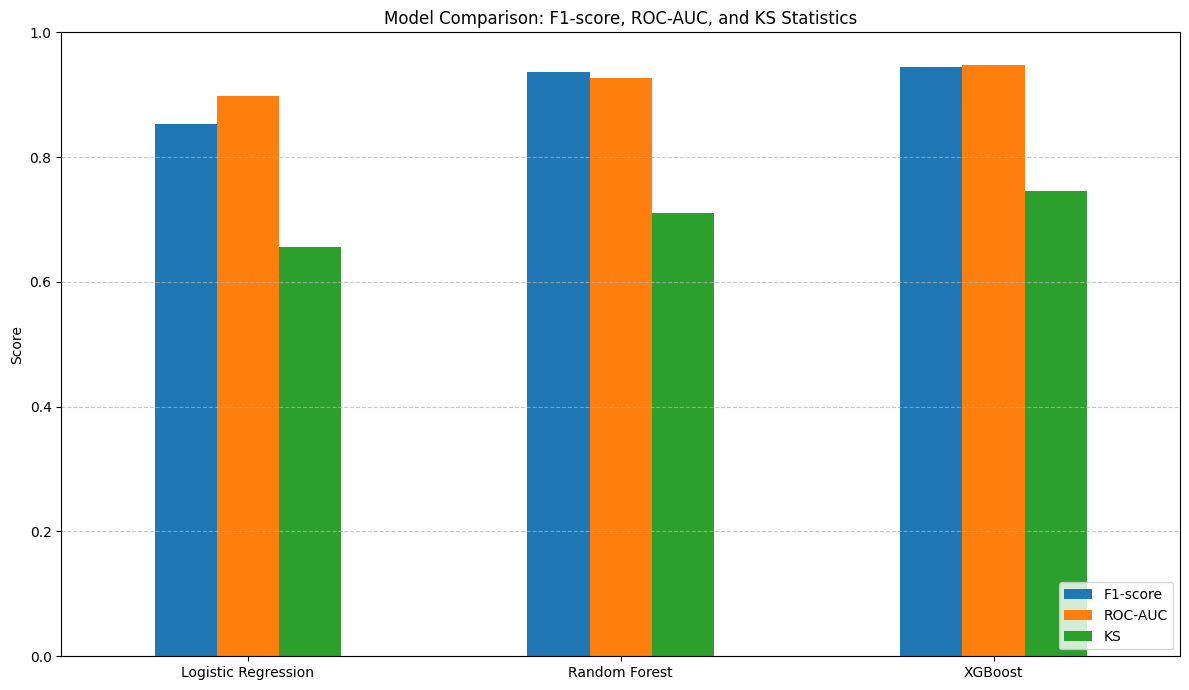

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import xgboost as xgb

# Khởi tạo mô hình
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

# Kết quả
results = {}

# Huấn luyện và đánh giá
for name, model in models.items():
    model.fit(X_train_smote, y_train_smote)
    y_pred = model.predict(X_test_processed)
    print(f"\n=== {name} ===")
    report = classification_report(y_test, y_pred, digits=3, output_dict=True)
    print(classification_report(y_test, y_pred, digits=3))

    results[name] = {
        "Precision": report['weighted avg']['precision'],
        "Recall": report['weighted avg']['recall'],
        "F1-score": report['weighted avg']['f1-score']
    }

from sklearn.metrics import f1_score, roc_auc_score

# Kết quả mới
results = {}

for name, model in models.items():
    model.fit(X_train_smote, y_train_smote)
    
    # Dự đoán nhãn (để tính F1)
    y_pred = model.predict(X_test_processed)
    # Dự đoán xác suất (để tính ROC-AUC và KS)
    y_probs = model.predict_proba(X_test_processed)[:, 1]

    # Tính toán các chỉ số
    f1 = f1_score(y_test, y_pred, average='weighted')
    roc_auc = roc_auc_score(y_test, y_probs)
    ks = calculate_ks(y_test, y_probs)

    results[name] = {
        "F1-score": f1,
        "ROC-AUC": roc_auc,
        "KS": ks
    }
    
    print(f"{name}: F1={f1:.3f}, AUC={roc_auc:.3f}, KS={ks:.3f}")

# Chuyển thành DataFrame
df_results = pd.DataFrame(results).T

# Vẽ biểu đồ so sánh
df_results.plot(kind="bar", figsize=(12, 7))
plt.title("Model Comparison: F1-score, ROC-AUC, and KS Statistics")
plt.ylabel("Score")
plt.ylim(0, 1.0) # KS và AUC thường nằm trong khoảng này
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("credit_risk_metrics.png")
plt.show()

In [34]:
# Sau khi vòng lặp for huấn luyện xong
# Lấy mô hình XGBoost từ dictionary models của bạn
xgboost_model = models["XGBoost"]

# Lưu thành file định dạng JSON
xgboost_model.save_model("xgb_loan_model.json")
import joblib

# Lưu mô hình
joblib.dump(xgboost_model, "xgb_loan_model.pkl")

['xgb_loan_model.pkl']

In [35]:
import joblib
# Lưu cả cục preprocessor (bao gồm cả StandardScaler và OneHotEncoder)
joblib.dump(preprocessor, 'preprocessor.pkl')

['preprocessor.pkl']

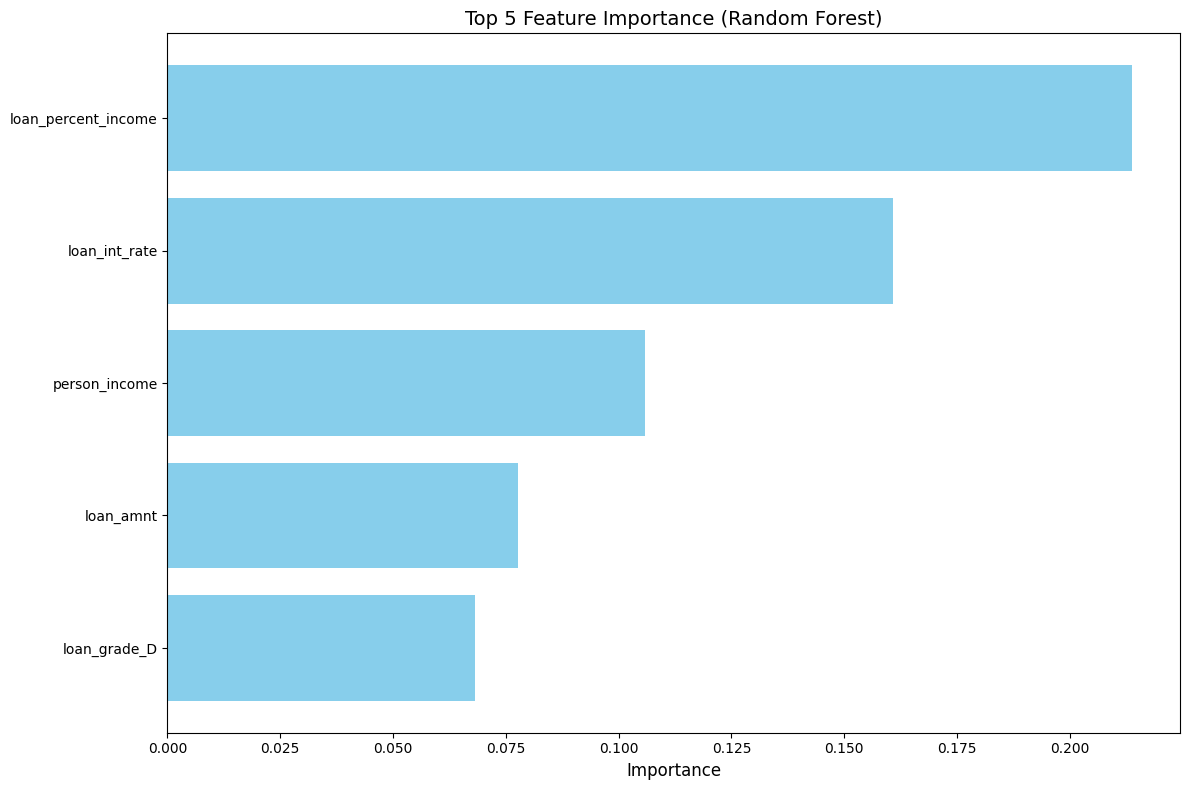

In [36]:
# ✅ Lấy tên các cột sau khi OneHotEncoder
ohe = preprocessor.named_transformers_['cat']
ohe_feature_names = ohe.get_feature_names_out(categorical_cols)

# ✅ Gộp lại danh sách tên đặc trưng
all_feature_names = numerical_cols + list(ohe_feature_names)
# ✅ Huấn luyện mô hình
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_smote, y_train_smote)

# ✅ Trích xuất độ quan trọng
importances = rf_model.feature_importances_

# ✅ Tạo DataFrame
feat_imp_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# ✅ Vẽ biểu đồ
plt.figure(figsize=(12, 8))
plt.barh(feat_imp_df['Feature'][:5][::-1], feat_imp_df['Importance'][:5][::-1], color='skyblue')
plt.title("Top 5 Feature Importance (Random Forest)", fontsize=14)
plt.xlabel("Importance", fontsize=12)
plt.tight_layout()
plt.show()


In [37]:

# Train model
model = XGBClassifier()
model.fit(X_train_smote, y_train_smote)
y_pred = model.predict(X_test_processed)
print(f"\n=== {name} ===")
print(classification_report(y_test, y_pred))




=== XGBoost ===
              precision    recall  f1-score   support

           0       0.95      0.98      0.97      9583
           1       0.89      0.73      0.80      1664

    accuracy                           0.95     11247
   macro avg       0.92      0.86      0.88     11247
weighted avg       0.94      0.95      0.94     11247



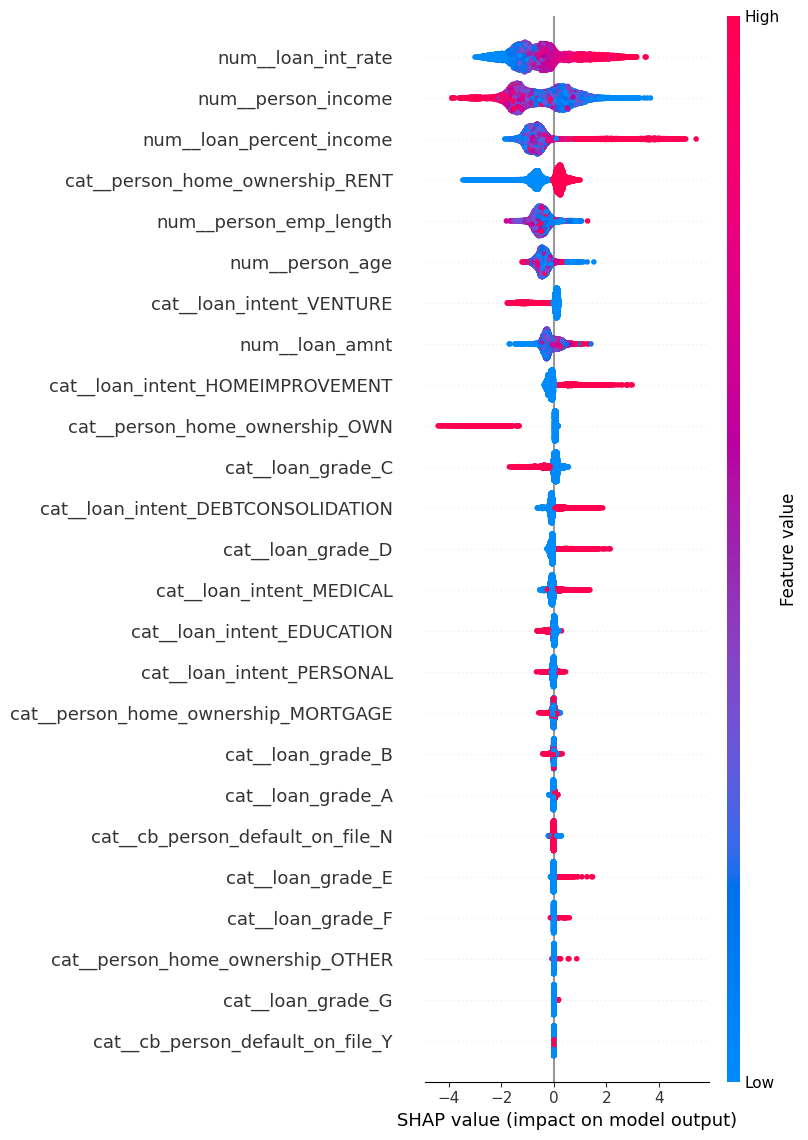

In [38]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(model)

# Tính SHAP value
shap_values = explainer.shap_values(X_test_processed)

# Tạo summary plot
shap.summary_plot(shap_values, X_test_processed, feature_names=preprocessor.get_feature_names_out(), max_display=50)

In [39]:
import shap
import pandas as pd
import numpy as np

# ✅ 1. Đồng bộ Index khi tạo DataFrame
# Chúng ta ép DataFrame mới phải dùng đúng Index của X_train gốc
feature_names = preprocessor.get_feature_names_out() 
X_train_df = pd.DataFrame(X_train_processed, columns=feature_names, index=X_train.index)

# ✅ 2. Tạo explainer và SHAP values (Tính toán 1 lần duy nhất)
# Dùng TreeExplainer sẽ nhanh và chính xác hơn cho XGBoost
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_train_df) 

# ✅ 3. Hàm giải thích đã được sửa logic truy xuất
def explain_local_with_waterfall_kr(index):
    # Kiểm tra xem index người dùng nhập có tồn tại trong bộ Train không
    if index not in X_train.index:
        print(f"❌ Index {index} không tồn tại trong bộ dữ liệu huấn luyện!")
        return

    print(f"\n🧾 [CUSTOMER DATA AT INDEX {index}]:")
    # Trích xuất dữ liệu gốc
    display(X_train.loc[[index]]) 

    # Lấy dữ liệu đã tiền xử lý của đúng dòng đó
    current_sample = X_train_df.loc[[index]]
    
    # Dự báo
    pred = model.predict(current_sample)[0]
    prob = model.predict_proba(current_sample)[0][1]
    truth = y_train.loc[index]

    # Giải thích ý nghĩa kết quả
    status_map = {0: "Approved (Good)", 1: "Rejected (Bad)"}
    
    print(f"\n🤖 [MODEL PREDICTION]: {status_map[pred]} (Probability of Default: {prob:.3f})")
    print(f"✅ [ACTUAL VALUE]: {status_map[truth]}")

    if pred == truth:
        print("🎉 Result: MATCH (Model learned this case correctly)")
    else:
        print("⚠️ Result: MISMATCH (Model predicted incorrectly for this case)")

    # 📊 Tìm vị trí số nguyên của index để vẽ SHAP
    idx_position = X_train_df.index.get_loc(index)
    
    print("\n📊 [SHAP WATERFALL EXPLANATION]:")
    # Logic vẽ biểu đồ cho binary classification
    expected_val = explainer.expected_value
    if isinstance(expected_val, list): expected_val = expected_val[1]
    
    shap.plots.waterfall(shap_values[idx_position], max_display=15)

# ✅ 4. Giao diện nhập Index (Hỗ trợ tìm nhanh các ca bị Rejected)
print(f"💡 Hint: Some Rejected (1) indices: {y_train[y_train == 1].index[:5].tolist()}")

while True:
    user_input = input(f"🔢 Enter Index to explain (q to quit): ")
    if user_input.lower() == 'q':
        print("👋 Finished.")
        break
    try:
        idx = int(user_input)
        explain_local_with_waterfall_kr(idx)
    except ValueError:
        print("❌ Please enter a valid numeric ID.")

💡 Hint: Some Rejected (1) indices: [58266, 33132, 15933, 55572, 24851]
👋 Finished.


In [40]:
# Tìm danh sách các Index mà thực tế khách hàng bị từ chối (Status = 1)
rejected_indices = y_train[y_train == 1].index.tolist()

print(f"Các số Index có kết quả bị Rejected (1) là: {rejected_indices[:100]}")

Các số Index có kết quả bị Rejected (1) là: [58266, 33132, 15933, 55572, 24851, 23011, 19847, 32621, 6410, 30755, 30256, 47875, 21169, 18476, 13982, 43864, 39977, 34352, 54847, 45926, 35250, 24448, 19003, 25300, 41565, 42114, 13293, 51059, 26970, 19525, 30464, 15053, 57938, 30378, 1457, 17041, 35920, 549, 4889, 35569, 32892, 1744, 23864, 44407, 43691, 28054, 24486, 28947, 33092, 33243, 1078, 42193, 13471, 27433, 23595, 47900, 10634, 51642, 40257, 26123, 40503, 21163, 24220, 20352, 3884, 40319, 27614, 24513, 9794, 8799, 43208, 8576, 26000, 42415, 50661, 16263, 44894, 1033, 54665, 13897, 20462, 7480, 20394, 47603, 224, 57477, 27080, 24921, 22575, 35603, 15020, 18099, 7570, 13227, 28218, 33351, 18908, 12554, 17295, 56378]
